## Codigo Vectorizado.

Red neuronal con dos 3 capas (entrada(2)-oculta(4)-salida(1)).

Emplea en cada capa la función sigmoide como activación.

Como función de pérdida usa MSE

Epoch 0, Loss: 0.3242
Epoch 1000, Loss: 0.1234
Epoch 2000, Loss: 0.1834
Epoch 3000, Loss: 0.1202
Epoch 4000, Loss: 0.1164
Epoch 5000, Loss: 0.1096
Epoch 6000, Loss: 0.0852
Epoch 7000, Loss: 0.0408
Epoch 8000, Loss: 0.0471
Epoch 9000, Loss: 0.0252
Epoch 10000, Loss: 0.0230
Epoch 11000, Loss: 0.0431
Epoch 12000, Loss: 0.0346
Epoch 13000, Loss: 0.0274
Epoch 14000, Loss: 0.0263
Final Loss: 0.0270


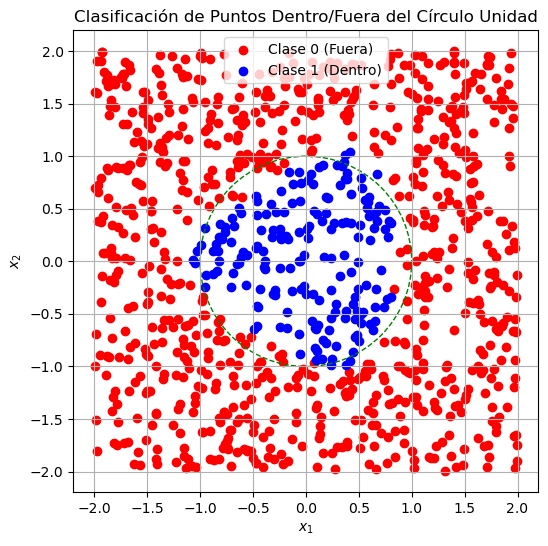

Pesos de la capa oculta (W1, b1):
[[ 0.25594749 -0.85582073]
 [-2.30255239  3.9883481 ]
 [-2.42407786 -4.12567339]
 [ 4.92342377 -0.26471888]]
[[ 0.6502504 ]
 [-3.54483351]
 [-3.41983792]
 [-3.63804943]]

Pesos de la capa de salida (W2, b2):
[[ 1.61971427 -7.22735415 -7.54700793 -7.4620554 ]]
[[3.38550374]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Función de activación sigmoide
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivada de la función sigmoide
def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

# Función de pérdida (Error Cuadrático Medio)
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Generación del dataset completo
M = 1000  # Número de puntos
X = np.random.uniform(-2., 2., ( 2, M ))
Y = np.array([1 if x1**2 + x2**2 <= 1 else 0 for x1, x2 in X.T]).reshape(1, -1)

# Inicialización de pesos y biases
input_dim = 2
hidden_dim = 4
output_dim = 1

W1 = np.random.randn(hidden_dim, input_dim)
b1 = np.zeros((hidden_dim,1))
W2 = np.random.randn(output_dim, hidden_dim)
b2 = np.zeros((output_dim,1))

# Parámetros de entrenamiento
learning_rate = 0.5
epochs = 15000
M_batch = 50

# Entrenamiento
for epoch in range(epochs):
    # Escoger un mini-lote de datos aleatorio para entrenar 
    index = np.random.randint(0, M - M_batch + 1)
    X_batch = X[:,index:index + M_batch]
    Y_batch = Y[:,index:index + M_batch]

    # Propagación hacia adelante para el mini-lote completo
    Z1 = W1@X_batch + b1
    A1 = sigmoid(Z1)
    Z2 = W2@A1 + b2
    A2 = sigmoid(Z2)

    # Cálculo de la pérdida para el mini-lote
    loss = mse(Y_batch, A2)

    # Propagación hacia atrás (backpropagation)
    delta2 =  (A2 - Y_batch) * sigmoid_derivative(Z2)
    dW2 =  delta2@A1.T 
    db2 = np.sum(delta2, axis=1, keepdims=True) 

    delta1 = (W2.T@delta2) * sigmoid_derivative(Z1)
    dW1 = delta1@X_batch.T
    db1 = np.sum(delta1, axis=1, keepdims=True) 

    # Actualización de pesos y biases
    W2 -= (learning_rate/M_batch) * dW2
    b2 -= (learning_rate/M_batch) * db2
    W1 -= (learning_rate/M_batch) * dW1
    b1 -= (learning_rate/M_batch) * db1

    # Monitorear el progreso
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Predicción de las clases
Z1 = W1@X + b1
A1 = sigmoid(Z1)
Z2 = W2@A1 + b2
A2 = sigmoid(Z2)
predictions = np.round(A2).flatten()
print(f"Final Loss: {mse(Y, A2):.4f}")

# Visualización de los resultados
plt.figure(figsize=(6, 6))
plt.scatter(X[0, predictions == 0], X[1, predictions == 0], c='red', label='Clase 0 (Fuera)')
plt.scatter(X[0, predictions == 1], X[1, predictions == 1], c='blue', label='Clase 1 (Dentro)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Clasificación de Puntos Dentro/Fuera del Círculo Unidad')
plt.legend()
plt.grid(True)

# Agregar la circunferencia de radio 1 centrada en el origen
circle = plt.Circle((0, 0), 1, color='green', fill=False, linestyle='--', label='Círculo Unidad')
plt.gca().add_artist(circle)

plt.show()

# Imprimir los pesos finales
print("Pesos de la capa oculta (W1, b1):")
print(W1)
print(b1)

print("\nPesos de la capa de salida (W2, b2):")
print(W2)
print(b2)
